In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)

In [2]:
X, y = mnist.data, mnist.target
print("x:", X)
print("y", y)
print(X.shape, "\n")
print(y.shape)

x: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
y ['5' '0' '4' ... '4' '5' '6']
(70000, 784) 

(70000,)


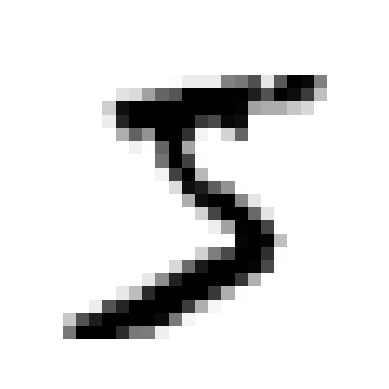

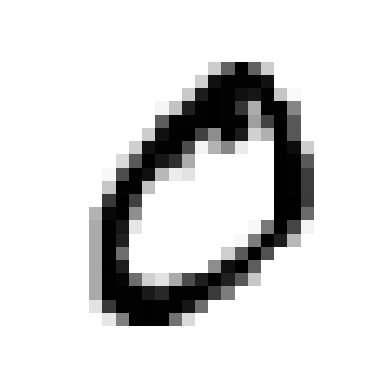

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 253 253 198 182 247 241   0   0   0   0   

In [ ]:
# Take a look on data
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary") # cmap="binary" to get a grayscale color map
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()
# where 0 is white and 255 is black
print(X[0])
# It's looks like a five, if we take a look on "y" we see a 5
print(y[0])

In [4]:
# Training and test set (it's already is splitted and shuffled)
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
# 70 000 всего 60 000 train, 10 000 test

In [ ]:
from sklearn.linear_model import SGDClassifier

# Training a Binary Classifier

# [True, False, False, True, False] boolean mask
# Тут создатся массив по длине как y_train но со значениями True или False
# то есть там где равно 5 будет true, в других местах false
y_train_5 = y_train == "5"  # True for all 5s, False for all other digits
y_test_5 = y_test == "5"

# Мы даем фичи и лейблы чтобы SGDClassifier мог определять
# Исходя из лейблов к фичам что будет означать тот или иной ответ
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)
# X0 =5, X1 = 0
sgd_clf.predict([X[0], X[1]])


array([ True, False])

## Performance Measures

In [ ]:
# Measuring Accuracy Using Cross-Validation
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")
# Точность 95%

array([0.95035, 0.96035, 0.9604 ])

In [ ]:
from sklearn.dummy import DummyClassifier

# DummyClassifier предсказывает самый частый класс. 
# True  = цифра 5
# False = не 5
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
# any(...) проверяет Есть ли хотя бы один True?
print(any(dummy_clf.predict(X_train)))
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")
# over 90%
# Можно иметь высокую accuracy,
# даже если модель вообще никогда не находит пятёрки.
# because only about 10% of the images are 5s
# This demonstrates why accuracy is generally not the preferred 
# performance measure for classifiers

# A much better way to evaluate the
# performance of a classifier is to look at the confusion matrix (CM).

False


array([0.90965, 0.90965, 0.90965])

In [ ]:
# IMPLEMENTING CROSS-VALIDATION

# custom cross validation, make same thing like Scikit-Learn 

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone 

skflods = StratifiedKFold(n_splits=3) # add shuffle=True if the dataset is not already shuffled
# делим на 3 части и сохраняем одинаковое соотношение классов
# 10% = True (5) ; 90% = False (не 5)

for train_index, test_index in skflods.split(X_train, y_train_5):
	clone_clf = clone(sgd_clf) 	# new empty model exact params, weights not copied 
	X_train_folds = X_train[train_index]
	y_train_folds = y_train_5[train_index]
	X_test_fold = X_train[test_index]
	y_test_fold = y_train_5[test_index]

	clone_clf.fit(X_train_folds, y_train_folds) # only on train
	y_pred = clone_clf.predict(X_test_fold) # predict on test fold
	n_correct = sum(y_pred == y_test_fold)
	print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


In [ ]:
# Confusion Matrices